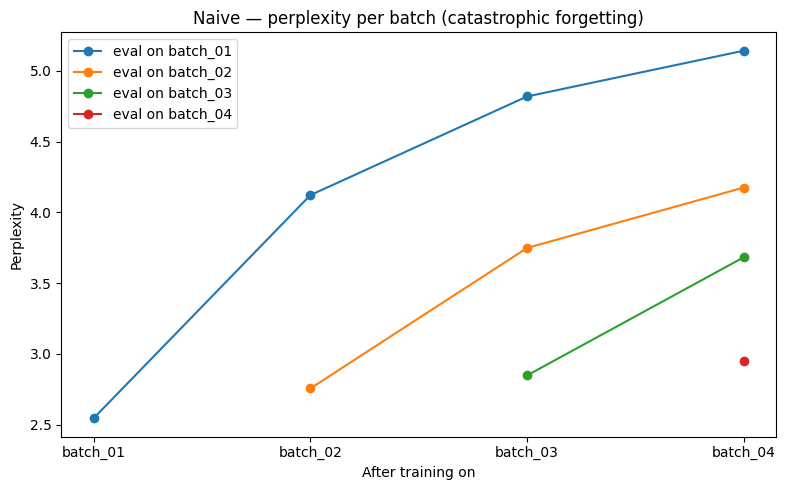

In [1]:
import json
import matplotlib.pyplot as plt

with open("../results/naive_results.json") as f:
    results = json.load(f)

batches = list(results.keys())
fig, ax = plt.subplots(figsize=(8, 5))

for eval_batch in batches:
    x, y = [], []
    for train_batch in batches:
        if eval_batch in results[train_batch]:
            x.append(train_batch)
            y.append(results[train_batch][eval_batch])
    ax.plot(x, y, marker="o", label=f"eval on {eval_batch}")

ax.set_title("Naive — perplexity per batch (catastrophic forgetting)")
ax.set_xlabel("After training on")
ax.set_ylabel("Perplexity")
ax.legend()
plt.tight_layout()
plt.show()

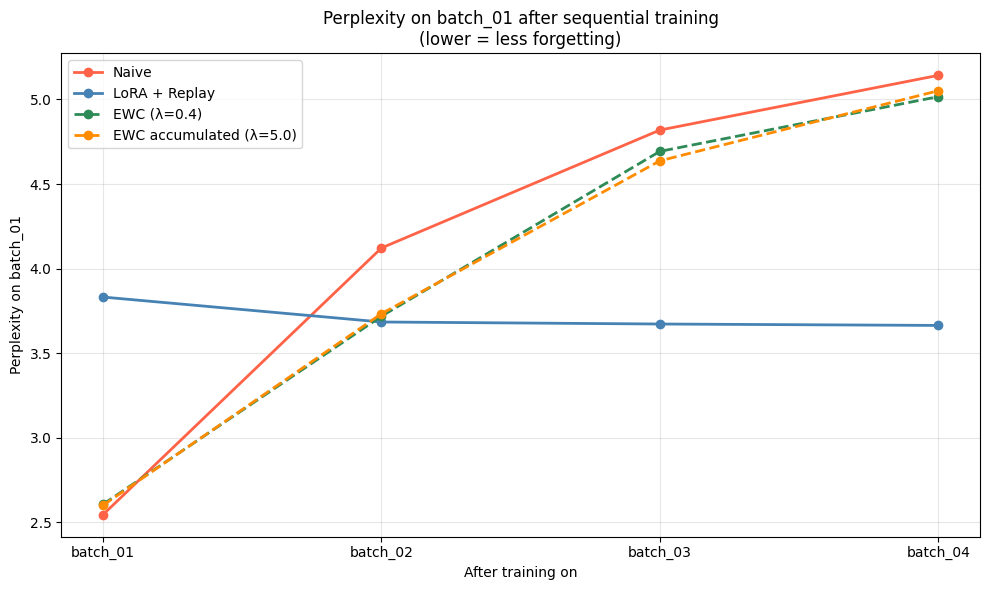

In [2]:
strategies = {
    "Naive": "../results/naive_results.json",
    "LoRA + Replay": "../results/lora_replay_results.json",
    "EWC (λ=0.4)": "../results/ewc_results.json",
    "EWC accumulated (λ=5.0)": "../results/ewc_accumulated_results.json",
}

colors = {
    "Naive": "tomato",
    "LoRA + Replay": "steelblue",
    "EWC (λ=0.4)": "seagreen",
    "EWC accumulated (λ=5.0)": "darkorange",
}
linestyles = {
    "Naive": "-",
    "LoRA + Replay": "-",
    "EWC (λ=0.4)": "--",
    "EWC accumulated (λ=5.0)": "--",
}

fig, ax = plt.subplots(figsize=(10, 6))

for strategy_name, path in strategies.items():
    with open(path) as f:
        results = json.load(f)

    train_batches = list(results.keys())
    perplexities = [results[b].get("batch_01") for b in train_batches]

    ax.plot(
        train_batches,
        perplexities,
        marker="o",
        label=strategy_name,
        color=colors[strategy_name],
        linestyle=linestyles[strategy_name],
        linewidth=2,
    )

ax.set_title("Perplexity on batch_01 after sequential training\n(lower = less forgetting)")
ax.set_xlabel("After training on")
ax.set_ylabel("Perplexity on batch_01")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

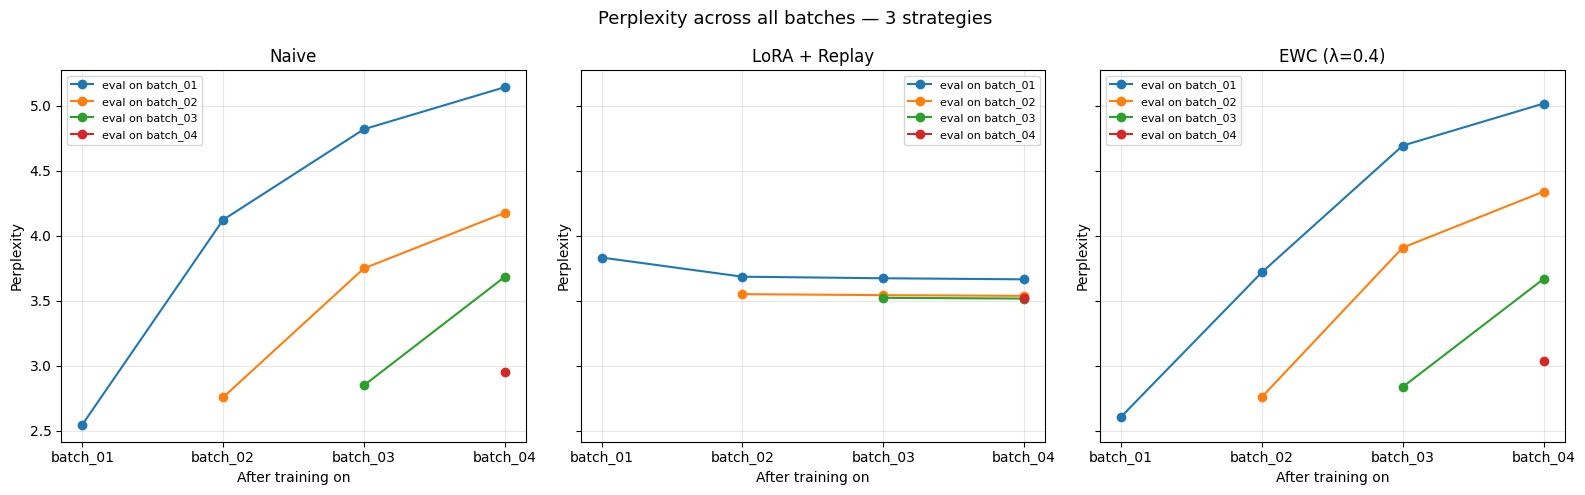

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, (strategy_name, path) in zip(axes, strategies.items()):
    with open(path) as f:
        results = json.load(f)

    train_batches = list(results.keys())

    for eval_batch in train_batches:
        x, y = [], []
        for train_batch in train_batches:
            if eval_batch in results[train_batch]:
                x.append(train_batch)
                y.append(results[train_batch][eval_batch])
        ax.plot(x, y, marker="o", label=f"eval on {eval_batch}")

    ax.set_title(strategy_name)
    ax.set_xlabel("After training on")
    ax.set_ylabel("Perplexity")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Perplexity across all batches — 3 strategies", fontsize=13)
plt.tight_layout()
plt.show()

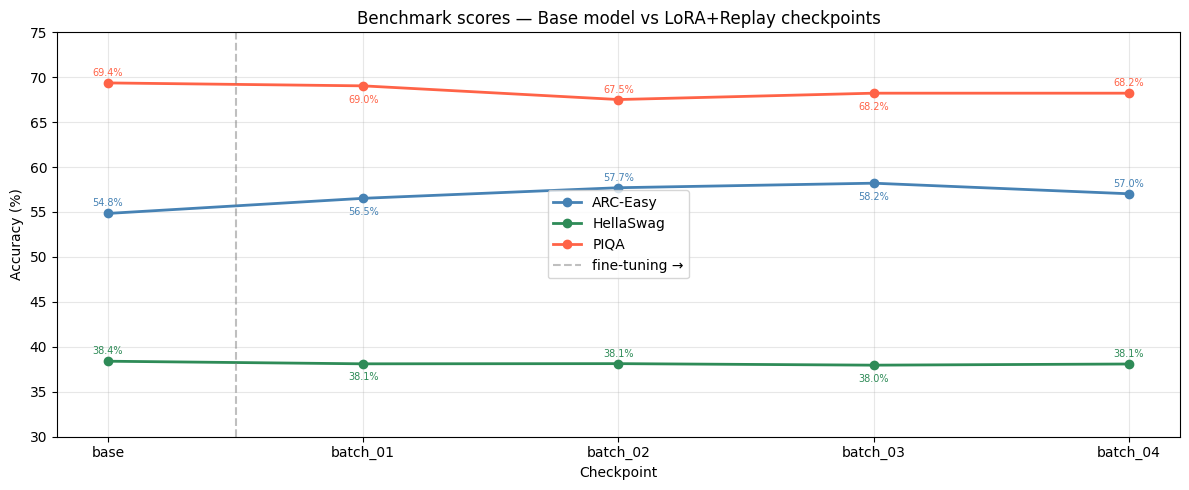

In [4]:
with open("../results/benchmark_results.json") as f:
    bench = json.load(f)

checkpoints = list(bench.keys())
tasks = ["arc_easy", "hellaswag", "piqa"]
bench_colors = {"arc_easy": "steelblue", "hellaswag": "seagreen", "piqa": "tomato"}
labels = {"arc_easy": "ARC-Easy", "hellaswag": "HellaSwag", "piqa": "PIQA"}

fig, ax = plt.subplots(figsize=(12, 5))

for task in tasks:
    scores = [bench[ckpt][task] * 100 for ckpt in checkpoints]
    ax.plot(checkpoints, scores, marker="o", label=labels[task],
            color=bench_colors[task], linewidth=2)
    for i, (ckpt, score) in enumerate(zip(checkpoints, scores)):
        offset_y = 5 if i % 2 == 0 else -12
        ax.annotate(f"{score:.1f}%", (ckpt, score),
                    textcoords="offset points", xytext=(0, offset_y),
                    fontsize=7, color=bench_colors[task], ha="center")

ax.axvline(x=0.5, color="gray", linestyle="--", alpha=0.5, label="fine-tuning →")
ax.set_title("Benchmark scores — Base model vs LoRA+Replay checkpoints")
ax.set_xlabel("Checkpoint")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(30, 75)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()